#  Emotion Detection CNN Project
This notebook trains a CNN to classify facial expressions from grayscale images (48x48).

##  1. Load & Preprocess the Data

In [1]:
# Import necessary libraries
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
# Define dataset directory paths
dataset_path = "E:\ml_project\data"
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\muska\AppData\Local\Temp\ipykernel_16576\1471339364.py:2: SyntaxWarning: invalid escape sequence '\m'
  dataset_path = "E:\ml_project\data"


In [3]:
# Define Data Augmentation with mild transformations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,  
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators without 'workers' (Handled by Keras automatically)
train_generator = train_datagen.flow_from_directory(
    train_dir, 
    target_size=(48, 48), 
    color_mode="grayscale",
    batch_size=64, 
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir, 
    target_size=(48, 48), 
    color_mode="grayscale",
    batch_size=64, 
    class_mode="categorical"
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [4]:
# Define Data Augmentation with mild transformations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,  
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators without 'workers' (Handled by Keras automatically)
train_generator = train_datagen.flow_from_directory(
    train_dir, 
    target_size=(48, 48), 
    color_mode="grayscale",
    batch_size=64, 
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir, 
    target_size=(48, 48), 
    color_mode="grayscale",
    batch_size=64, 
    class_mode="categorical"
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [5]:
# Compute class weights to handle imbalanced dataset
train_classes = np.array(train_generator.classes)
class_labels = np.unique(train_classes)
class_weights = compute_class_weight('balanced', classes=class_labels, y=train_classes)
class_weights = np.clip(class_weights, 0.5, 2.0)  # Lower max cap to 2.0 to prevent extreme bias
class_weights_dict = dict(enumerate(class_weights))

print("Final Class Weights:", class_weights_dict)

Final Class Weights: {0: np.float64(1.0266046844269623), 1: np.float64(2.0), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [6]:
from tensorflow.keras.regularizers import l2

# Define an improved CNN architecture
model = Sequential([
    Input(shape=(48,48,1)),

    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same', kernel_regularizer=l2(1e-4)),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(7, activation='softmax')  # 7 Emotion Classes
])

In [7]:
# Define optimizer with weight decay
optimizer = AdamW(learning_rate=3e-4, weight_decay=1e-5)

# Compile model with label smoothing
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  
    optimizer=optimizer,
    metrics=["accuracy"]
)

# Show model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,931,719 (22.63 MB)

 Trainable params: 5,930,823 (22.62 MB)

 Non-trainable params: 896 (3.50 KB)

In [8]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
)

In [9]:
 history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    class_weight=class_weights_dict,
    callbacks=[early_stopping, lr_scheduler]
)

c:\Users\muska\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 208s 455ms/step - accuracy: 0.1811 - loss: 2.0296 - val_accuracy: 0.2629 - val_loss: 2.0692 - learning_rate: 3.0000e-04
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 216s 480ms/step - accuracy: 0.2322 - loss: 1.8221 - val_accuracy: 0.2850 - val_loss: 1.9718 - learning_rate: 3.0000e-04
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 220s 489ms/step - accuracy: 0.2708 - loss: 1.7599 - val_accuracy: 0.2257 - val_loss: 1.9290 - learning_rate: 3.0000e-04
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 212s 472ms/step - accuracy: 0.2701 - loss: 1.7107 - val_accuracy: 0.3197 - val_loss: 1.8612 - learning_rate: 3.0000e-04
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 200s 445ms/step - accuracy: 0.2832 - loss: 1.6732 - val_accuracy: 0.3870 - val_loss: 1.7606 - learning_rate: 3.0000e-04
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 241s 535ms/step - accuracy: 0.3727 - loss: 1.5885 - val_accuracy: 0.4610 - val_loss: 1.6467 - learning_rate: 3.0000e-04
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 

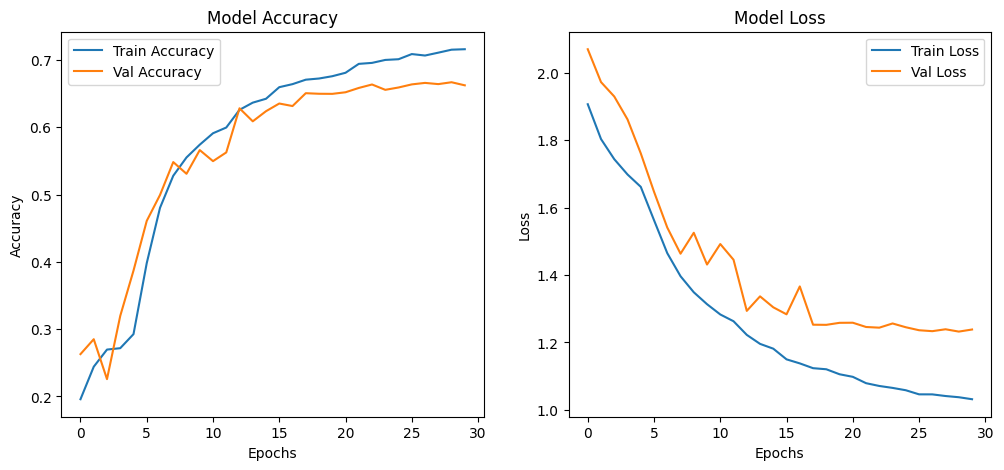

In [17]:
def plot_metrics(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.show()

plot_metrics(history)


In [18]:
model.save("E:\ml_project\cnn_improved.h5")

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\muska\AppData\Local\Temp\ipykernel_16576\2432545527.py:1: SyntaxWarning: invalid escape sequence '\m'
  model.save("E:\ml_project\cnn_improved.h5")


In [19]:
# Evaluate the model on the FER-2013 test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.6763 - loss: 1.2171
Test Accuracy: 66.70%
Test Loss: 1.2323


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


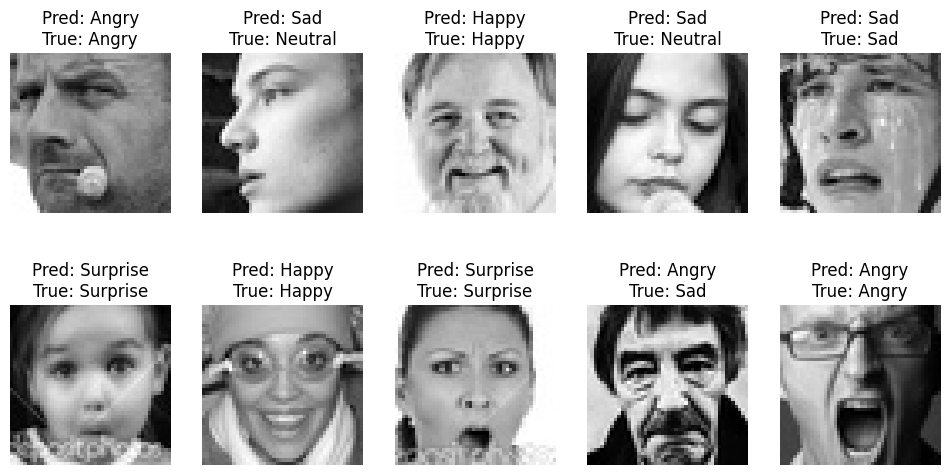

In [20]:
import numpy as np

# Get a batch of test images and labels
images, labels = next(iter(test_generator))

# Predict on the batch
predictions = model.predict(images)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

# Class labels for FER-2013
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# Plot sample images with predicted labels
plt.figure(figsize=(12,6))
for i in range(10):  # Show first 10 images
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"Pred: {emotion_labels[predicted_classes[i]]}\nTrue: {emotion_labels[true_classes[i]]}")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


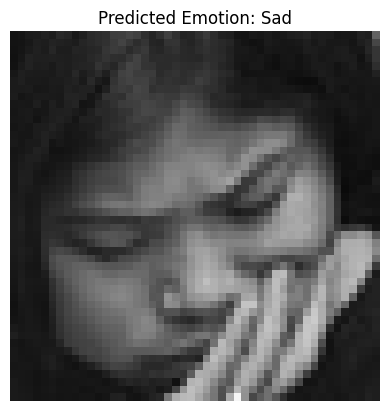

In [14]:
import random

# Pick a random test image
random_index = random.randint(0, len(test_generator.filenames)-1)
img_path = os.path.join(test_dir, test_generator.filenames[random_index])

# Load and preprocess the image
def predict_emotion(img_path, model):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48,48))
    img = img / 255.0  # Normalize
    img = np.expand_dims(img, axis=0)
    img = np.expand_dims(img, axis=-1)

    prediction = model.predict(img)
    emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
    predicted_emotion = emotion_labels[np.argmax(prediction)]
    
    plt.imshow(cv2.imread(img_path))
    plt.title(f"Predicted Emotion: {predicted_emotion}")
    plt.axis("off")
    plt.show()

predict_emotion(img_path, model)

##  5. Save the Model for Deployment

In [21]:
model.save('emotion_model.h5')
print('Model saved successfully!')

Model saved successfully!


##  6. Define Prediction Function

In [22]:
from tensorflow.keras.models import load_model
import numpy as np
import cv2

model = load_model('emotion_model.h5')

def predict_emotion(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48, 48))
    img = img.reshape(1, 48, 48, 1) / 255.0
    pred = model.predict(img)
    return np.argmax(pred), pred

##  7. Deployment via Streamlit

```python
import streamlit as st
from PIL import Image
import numpy as np
import cv2
from tensorflow.keras.models import load_model

model = load_model("emotion_model.h5")
labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

st.title("Emotion Detector")
file = st.file_uploader("Upload an image", type=["jpg", "png", "jpeg"])

if file:
    img = Image.open(file).convert("L").resize((48, 48))
    img_array = np.array(img).reshape(1, 48, 48, 1) / 255.0
    prediction = model.predict(img_array)
    st.image(file, caption="Uploaded Image", use_column_width=True)
    st.write("Predicted Emotion:", labels[np.argmax(prediction)])
```
Run with `streamlit run app.py`